In [1]:
import seaborn as sns
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import numpy as np
import warnings
import sys
warnings.filterwarnings('ignore')

d:\Python\AIN701_Group_04\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Thêm src vào path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [ ]:
# import sys
# for mod in list(sys.modules):
#     if mod.startswith('src'):
#         del sys.modules[mod]

In [18]:
import sys
from pathlib import Path
import joblib
import pandas as pd

# 1. Tìm project_root (chứa folder 'src')
current = Path.cwd().resolve()
project_root = next((p for p in [current, *current.parents] if (p / "src").exists()), None)
if project_root is None:
    raise FileNotFoundError("Không tìm thấy thư mục 'src'")
sys.path.insert(0, str(project_root))
print("project_root =", project_root)

# 2. Load model đã train (tự tìm, không cần biết chính xác path)
model_path = list(project_root.rglob('lightgbm.pkl'))[0]
best_model = joblib.load(model_path)
print("Đã load model:", type(best_model).__name__, "từ", model_path)

# 3. Load data đã xử lý
processed_dir = project_root / 'data' / 'processed'
X_train = pd.read_pickle(processed_dir / 'X_train.pkl')
X_test = pd.read_pickle(processed_dir / 'X_test.pkl')
y_train = pd.read_pickle(processed_dir / 'y_train.pkl')
y_test = pd.read_pickle(processed_dir / 'y_test.pkl')
print("X_train:", X_train.shape, " X_test:", X_test.shape)

# 4. Import hàm SHAP
from src.models.shap_analysis import (
    get_explainer, compute_shap_values, plot_global_summary, plot_global_bar,
    get_rejected_cases, plot_local_waterfall, get_top_features_for_case
)

THRESHOLD = 0.176  # đã chốt ở bước trước
figures_dir = project_root / 'src' / 'reports' / 'figures'

project_root = D:\Python\AIN701_Group_04\demo
Đã load model: LGBMClassifier từ D:\Python\AIN701_Group_04\demo\data\models\lightgbm.pkl
X_train: (204277, 24)  X_test: (51070, 24)


Quyết định: Reject  (xác suất default = 0.9391)
          feature  value  shap_value
0        LoanTerm  60.00   -1.664123
1             Age  19.00    0.669754
2    InterestRate  22.50    0.568239
3        DTIRatio   0.85   -0.527927
4  NumCreditLines   5.00   -0.430339


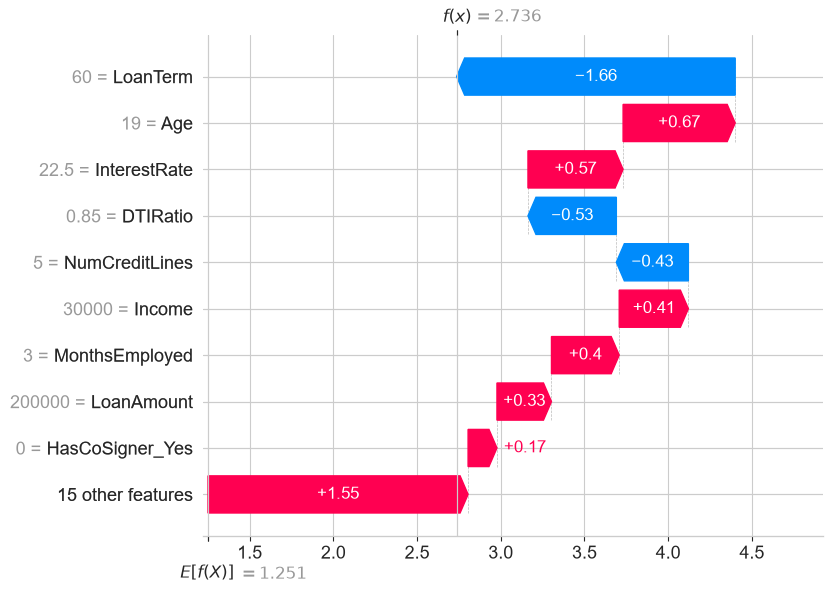

In [19]:
from src.models.predict_model import load_feature_names, predict_single

feature_names = load_feature_names(project_root)

# Giả lập 1 "form input" — chỉ cần đổi giá trị trong dict này để test nhiều case khác nhau
raw_input = {
    'Age': 19, 'Income': 30000, 'LoanAmount': 200000, 'CreditScore': 450,
    'MonthsEmployed': 3, 'NumCreditLines': 5, 'InterestRate': 22.5, 'LoanTerm': 60,
    'DTIRatio': 0.85, 'Education': 'High School', 'EmploymentType': 'Unemployed',
    'MaritalStatus': 'Single', 'HasMortgage': 'No', 'HasDependents': 'No',
    'LoanPurpose': 'Business', 'HasCoSigner': 'No'
}

result = predict_single(best_model, raw_input, feature_names)
print(f"Quyết định: {result['decision']}  (xác suất default = {result['probability']:.4f})")

# Chạy SHAP cho đúng case này
shap_values_single = explainer.shap_values(result['X_input'])
top_features = get_top_features_for_case(shap_values_single, result['X_input'], idx=0)
print(top_features)

plot_local_waterfall(explainer, shap_values_single, result['X_input'], idx=0)

Đã load model: LGBMClassifier


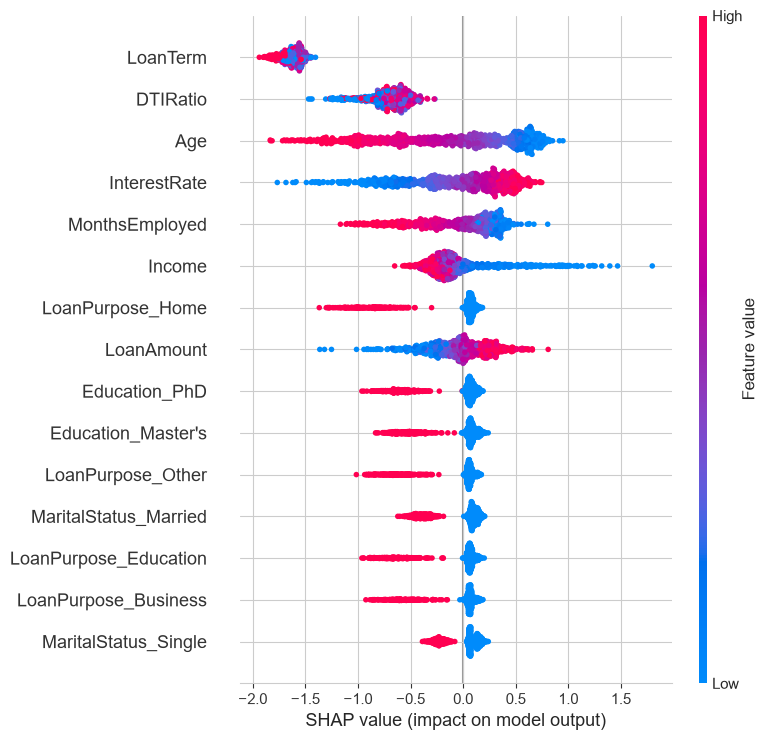

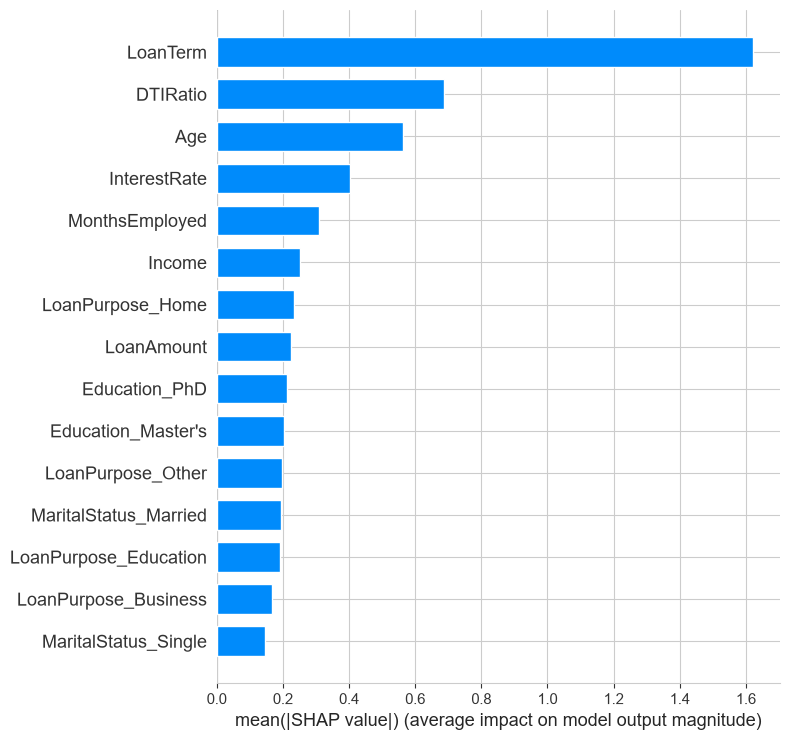

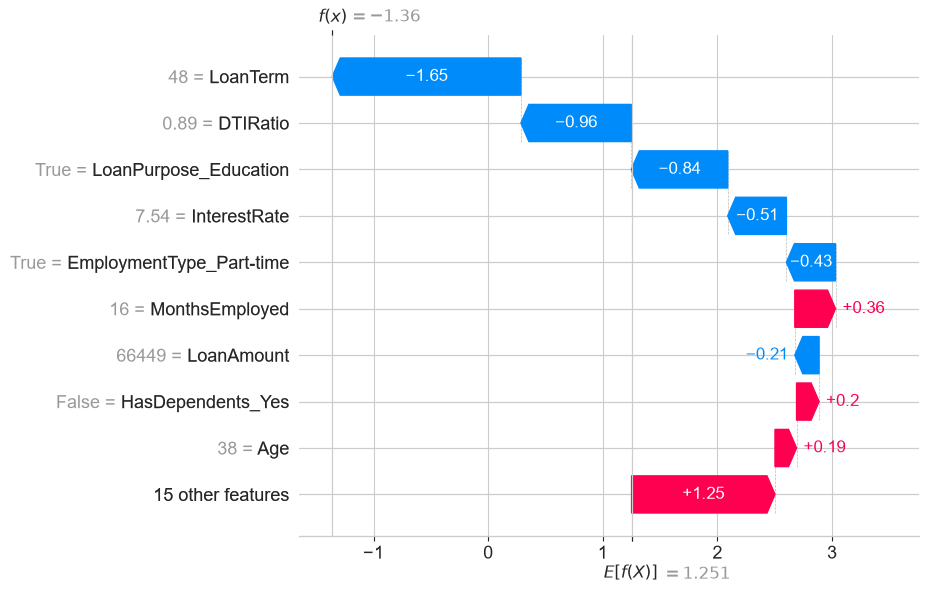

                    feature value  shap_value
0                  LoanTerm    48   -1.645649
1                  DTIRatio  0.89   -0.963384
2     LoanPurpose_Education  True   -0.840603
3              InterestRate  7.54   -0.512089
4  EmploymentType_Part-time  True   -0.428346


In [20]:
from src.models.shap_analysis import (
    get_explainer, compute_shap_values, plot_global_summary, plot_global_bar,
    get_rejected_cases, plot_local_waterfall, get_top_features_for_case
)

import joblib

model_path = project_root / 'data' / 'models' / 'lightgbm.pkl'  # kiểm tra đúng path em đã lưu lúc trước
best_model = joblib.load(model_path)
print("Đã load model:", type(best_model).__name__)

THRESHOLD = 0.176  # đã chốt ở bước trước
figures_dir = project_root / 'src' / 'reports' / 'figures'

explainer = get_explainer(best_model)
X_sample, shap_values = compute_shap_values(explainer, X_test, sample_size=1000)

# Global
plot_global_summary(shap_values, X_sample, save_path=figures_dir / 'shap_summary.png')
plot_global_bar(shap_values, X_sample, save_path=figures_dir / 'shap_importance_bar.png')

# Local — chọn 1 case bị từ chối thật để giải thích
rejected_idx, proba = get_rejected_cases(best_model, X_sample, THRESHOLD)
case_idx = rejected_idx[0]
plot_local_waterfall(explainer, shap_values, X_sample, case_idx,
                      save_path=figures_dir / 'shap_waterfall_example.png')

top_features = get_top_features_for_case(shap_values, X_sample, case_idx)
print(top_features)